In [178]:
# Changing Jupyter server from the root folder of the workspace to out notebook folder
%cd game-behavior-analytics/data_analysis_notebook/

[Errno 2] No such file or directory: 'game-behavior-analytics/data_analysis_notebook/'
/Users/suvadeep.mukherjee/Documents/game-behavior-intervention-study/game-behavior-analytics/data_analysis_notebook


/opt/anaconda3/envs/cheating_env/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


### Important necessary libraries

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path
import re
import os
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

### Loading the dataset

In [193]:
# Set display options for better readability
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 1000)
# pd.set_option('display.float_format', '{:.3f}'.format)

project_root = Path('../')
data_path = project_root / "data" / "combined_dataset.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head(15)

Dataset shape: (1349, 107)

First 5 rows:


,prolific_id,word_creation_skill_level,total_words_practice_round,cheating_rate_practice_round,total_words_main_round,cheating_rate_main_round,cheating_lying_rate,performance_score_excluding_cheated_words,performance_score_including_cheated_words,motivational_message_id,...,PME_disengagement_4,PME_disengagement_5,PME_disengagement_6,gender,ethnicity,native_language,highest_education,online_tests_taken_last_3_years,feedback,age
0,664db585355de70e17541e5a,6,2,1.0,8,1.000000,1.000000,0,30,performance_accomplishments_2,...,5.0,5.0,6.0,Male,Asian / Pacific Islander,Chinese Mandarin,Doctorate degree,0.0,I genuinely enjoyed participating in this chal...,31.0
1,67becbc7425071ed32061ea8,8,0,0.0,5,1.000000,1.000000,0,22,emotional_arousal_1,...,3.0,3.0,2.0,Female,White or Caucasian,English,Bachelor’s degree,3.0,I found dragging the letters a bit hectic. It ...,26.0
2,6777abdac98bf6f7a03ac4da,3,3,0.0,11,0.000000,0.000000,32,32,dissonance_arousal_3,...,1.0,3.0,1.0,Male,White or Caucasian,English,Bachelor’s degree,0.0,Very enjoyable,29.0
3,6740be3bb017538cf65cd419,8,3,0.0,4,0.000000,0.000000,8,8,reference_group_identification_2,...,5.0,6.0,6.0,Male,Black or African American,English,Master’s degree,20.0,This is really an amazing study.,29.0
4,665a16dd2db5a0dff976ea9b,6,5,1.0,10,1.000000,1.000000,0,52,relatedness_3,...,4.0,1.0,1.0,Female,White or Caucasian,English,"Some high school, no diploma",5.0,"It was very fun, I would of preferred to use t...",22.0
5,5ea2f8ff57400807b6f53ddf,6,2,0.0,5,0.200000,1.000000,4,4,social_sanctions_1,...,3.0,5.0,4.0,Male,White or Caucasian,English,"Some college credit, no degree",1032.0,I enjoyed the word task very much it was diffe...,33.0
6,55e876f25e4d360012cc283d,3,2,0.0,8,0.000000,0.000000,14,14,autonomy_3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,55c3b47dfdf99b52bdba86da,4,7,0.0,7,0.000000,0.000000,26,26,competence_1,...,3.0,5.0,4.0,Female,White or Caucasian,English,Bachelor’s degree,30.0,NaN,26.0
8,62b35b7ceadb050497fbbe58,5,2,0.0,9,0.000000,0.000000,18,18,cognitive_inconsistency_3,...,5.0,5.0,5.0,Female,White or Caucasian,English,Bachelor’s degree,1.0,NaN,32.0
9,62b626b7cc2365d4e7f5c5aa,4,3,0.0,9,1.000000,1.000000,0,20,self_concept_1,...,2.0,6.0,1.0,Male,Asian / Pacific Islander,English,Bachelor’s degree,2.0,To see how the message influences us doing the...,36.0


### Handing missing values and datatype transformation

In [50]:
# missing_values = df.isnull().sum()
# print("Columns with missing values:")
# print(missing_values[missing_values > 0])

# # Check if there are any rows where last mandatory entry in the survey i.e. PME_disengagement_3 is missing
# df = df[~((df['PME_disengagement_3'] == 0) | (df['PME_disengagement_3'].isna()))]

# df['motivational_message_id'] = df['motivational_message_id'].fillna('control').replace('', 'control')
# df['theory'] = df['theory'].fillna('No Theory').replace('', 'No Theory')

# df

Columns with missing values:
motivational_message_id             62
theory                              62
time_spent_on_message               68
Usability_1                        112
Usability_2                        112
                                  ... 
native_language                    112
highest_education                  112
online_tests_taken_last_3_years    112
feedback                           655
age                                112
Length: 89, dtype: int64
Type of age in combined_df: int64


,prolific_id,word_creation_skill_level,total_words_practice_round,cheating_rate_practice_round,total_words_main_round,cheating_rate_main_round,cheating_lying_rate,performance_score,motivational_message_id,theory,...,PME_disengagement_4,PME_disengagement_5,PME_disengagement_6,gender,ethnicity,native_language,highest_education,online_tests_taken_last_3_years,feedback,age
0,664db585355de70e17541e5a,6,2,1.0,8,1.000000,1.000000,0.000000,performance_accomplishments_2,Self-Efficacy Theory,...,5.0,5.0,6.0,Male,Asian / Pacific Islander,Chinese Mandarin,Doctorate degree,0.0,I genuinely enjoyed participating in this chal...,31
1,67becbc7425071ed32061ea8,8,0,0.0,5,1.000000,1.000000,0.000000,emotional_arousal_1,Self-Efficacy Theory,...,3.0,3.0,2.0,Female,White or Caucasian,English,Bachelor’s degree,3.0,I found dragging the letters a bit hectic. It ...,26
2,6777abdac98bf6f7a03ac4da,3,3,0.0,11,0.000000,0.000000,11.668454,dissonance_arousal_3,Cognitive Dissonance Theory,...,1.0,3.0,1.0,Male,White or Caucasian,English,Bachelor’s degree,0.0,Very enjoyable,29
3,6740be3bb017538cf65cd419,8,3,0.0,4,0.000000,0.000000,2.172515,reference_group_identification_2,Social Norms Theory,...,5.0,6.0,6.0,Male,Black or African American,English,Master’s degree,20.0,This is really an amazing study.,29
4,665a16dd2db5a0dff976ea9b,6,5,1.0,10,1.000000,1.000000,0.000000,relatedness_3,Self-Determination Theory,...,4.0,1.0,1.0,Female,White or Caucasian,English,"Some high school, no diploma",5.0,"It was very fun, I would of preferred to use t...",22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,5f4183ee48465a339d3dc81d,2,4,0.0,8,0.000000,0.000000,8.025074,injunctive_norms_2,Social Norms Theory,...,5.0,6.0,6.0,Female,White or Caucasian,english,Bachelor’s degree,100.0,NaN,25
1345,67ace92ea07efb272f6cf151,7,3,0.0,6,0.000000,0.000000,3.899893,cognitive_inconsistency_2,Cognitive Dissonance Theory,...,6.0,6.0,4.0,Male,White or Caucasian,English,Trade/technical/vocational training,20.0,NaN,31
1346,673b1359d4a110d4ef515552,6,3,0.0,4,0.000000,0.000000,2.338610,control,No Theory,...,6.0,4.0,4.0,Female,Black or African American,"English language, Yoruba language",Master’s degree,25.0,I think it is a good study and I am really gla...,35
1347,66a8f8a29b882318b60ef2e5,5,1,0.0,3,1.000000,1.000000,0.000000,cognitive_inconsistency_3,Cognitive Dissonance Theory,...,1.0,5.0,4.0,Male,White or Caucasian,English,Trade/technical/vocational training,10.0,NaN,31


In [194]:
if 'age' in df.columns:
    df['age'] = df['age'].fillna(-1).astype(int)
    # Replace -1 with NaN if you want to preserve missing values
    df['age'] = df['age'].replace(-1, np.nan)
        
print(f"Type of age in combined_df: {df['age'].dtype}")

Type of age in combined_df: float64


In [195]:
df = df[df['motivational_message_id'].notna() & (df['motivational_message_id'].astype(str).str.strip() != '')]
def extract_concept_and_variation(message_id):
    if pd.isna(message_id):
        return 'Unknown', 'Unknown'
    
    message_str = str(message_id).lower()
    
    # Use regex to find the pattern: anything followed by underscore and a number
    # This will match the last occurrence of _[number] in the string
    match = re.match(r'^(.+)_([123])$', message_str)
    
    if match:
        concept = match.group(1)  # Everything before the last _[number]
        variation = match.group(2)  # The number (1, 2, or 3)
    else:
        # Fallback: if no number pattern found, treat whole string as concept
        concept = message_str
        variation = '1'
    
    return concept, variation

df['concept'], df['variation'] = zip(*df['motivational_message_id'].apply(extract_concept_and_variation))

### Create new features and integrate them into the dataset

In [196]:
base_cols = [
    "prolific_id", "age", "gender", "ethnicity", "native_language", "highest_education", "online_tests_taken_last_3_years", "motivational_message_id", "concept", "theory", "time_spent_on_message", "word_creation_skill_level", "cheating_rate_practice_round", "total_words_practice_round", "cheating_rate_main_round", "total_words_main_round", "cheating_lying_rate", "performance_score_excluding_cheated_words", "performance_score_including_cheated_words", "used_external_resources","confessed_words_count", "cheating_main_round", "has_page_left", "total_time_page_left", "has_mouse_inactivity", "total_time_mouse_inactivity", "valid_7_letter_words", "valid_8_letter_words"
]

In [197]:
# Define message perception text columns (qualitative data)
message_perception_cols = [
    "message_comprehend",
    "message_confidence", 
    "message_attitude", 
    "message_impact", 
    "message_persistence", 
    "message_suggestion",
    "feedback"
]

# Define column groups
usability = [col for col in df.columns if re.match(r'^Usability_\d+$', col)]
task_engagement = [col for col in df.columns if re.match(r'^Engagement_\d+$', col)]
task_satisfaction = [col for col in df.columns if re.match(r'^Satisfaction_\d+$', col)]
message_perceived_understanding = [col for col in df.columns if re.match(r'^Understand_\d+$', col)]
PME_on_honest_task_completion = [col for col in df.columns if re.match(r'^PME_honest_playing_\d+$', col)]
PME_on_task_performance = [col for col in df.columns if re.match(r'^PME_performance_\d+$', col)]
PME_on_task_experience = [col for col in df.columns if re.match(r'^PME_UX_\d+$', col)]

# Self-determination theory components
autonomy_need_satisfaction = [col for col in df.columns if re.match(r'^PME_aut_sat_\d+$', col)]
competence_need_satisfaction = [col for col in df.columns if re.match(r'^PME_com_sat_\d+$', col)]
relatedness_need_satisfaction = [col for col in df.columns if re.match(r'^PME_rel_sat_\d+$', col)]
autonomy_need_frustration = [col for col in df.columns if re.match(r'^PME_aut_fru_\d+$', col)]
competence_need_frustration = [col for col in df.columns if re.match(r'^PME_com_fru_\d+$', col)]
relatedness_need_frustration = [col for col in df.columns if re.match(r'^PME_rel_fru_\d+$', col)]

# Self-efficacy components
performance_accomplishments = [col for col in df.columns if re.match(r'^PME_efficacy_PA_\d+$', col)]
vicarious_experience = [col for col in df.columns if re.match(r'^PME_efficacy_VE_\d+$', col)]
verbal_persuasion = [col for col in df.columns if re.match(r'^PME_efficacy_VP_\d+$', col)]
emotional_arousal = [col for col in df.columns if re.match(r'^PME_efficacy_EA_\d+$', col)]

# Social norms components
injunctive_norms = [col for col in df.columns if re.match(r'^PME_inj_norm_\d+$', col)]
descriptive_norms = [col for col in df.columns if re.match(r'^PME_des_norm_\d+$', col)]
reference_group_identification = [col for col in df.columns if re.match(r'^PME_ref_norm_\d+$', col)]
social_sanctions = [col for col in df.columns if re.match(r'^PME_sanc_norm_\d+$', col)]

# Cognitive dissonance components
cognitive_discomfort = [col for col in df.columns if re.match(r'^PME_dissonance_\d+$', col)]

# Moral disengagement components
moral_disengagement = [col for col in df.columns if re.match(r'^PME_disengagement_\d+$', col)]

# Calculate the average for each group and assign to new variables
df['usability'] = df[usability].mean(axis=1)
df['task_engagement'] = df[task_engagement].mean(axis=1)
df['task_satisfaction'] = df[task_satisfaction].mean(axis=1)
df['message_understanding'] = df[message_perceived_understanding].mean(axis=1)
df['PME_on_honest_task_completion'] = df[PME_on_honest_task_completion].mean(axis=1)
df['PME_on_task_performance'] = df[PME_on_task_performance].mean(axis=1)
df['PME_on_task_experience'] = df[PME_on_task_experience].mean(axis=1)

# SDT components
df['autonomy_need_satisfaction'] = df[autonomy_need_satisfaction].mean(axis=1)
df['competence_need_satisfaction'] = df[competence_need_satisfaction].mean(axis=1)
df['relatedness_need_satisfaction'] = df[relatedness_need_satisfaction].mean(axis=1)
df['autonomy_need_frustration'] = df[autonomy_need_frustration].mean(axis=1)
df['competence_need_frustration'] = df[competence_need_frustration].mean(axis=1)
df['relatedness_need_frustration'] = df[relatedness_need_frustration].mean(axis=1)

# Calculate overall need fulfillment scores
df['autonomy_need_fulfillment'] = df['autonomy_need_satisfaction'] - df['autonomy_need_frustration']
df['competence_need_fulfillment'] = df['competence_need_satisfaction'] - df['competence_need_frustration']
df['relatedness_need_fulfillment'] = df['relatedness_need_satisfaction'] - df['relatedness_need_frustration']
df['overall_need_fulfillment'] = df[['autonomy_need_fulfillment', 'competence_need_fulfillment', 'relatedness_need_fulfillment']].mean(axis=1)

# Self-efficacy components
df['performance_accomplishments'] = df[performance_accomplishments].mean(axis=1)
df['vicarious_experience'] = df[vicarious_experience].mean(axis=1)
df['verbal_persuasion'] = df[verbal_persuasion].mean(axis=1)
df['emotional_arousal'] = df[emotional_arousal].mean(axis=1)
df['task_specific_self_efficacy'] = df[['performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal']].mean(axis=1)

# Social norms components
df['injunctive_norms'] = df[injunctive_norms].mean(axis=1)
df['descriptive_norms'] = df[descriptive_norms].mean(axis=1)
df['reference_group_identification'] = df[reference_group_identification].mean(axis=1)
df['social_sanctions'] = df[social_sanctions].mean(axis=1)
df['norm_perception'] = df[['injunctive_norms', 'descriptive_norms', 'reference_group_identification', 'social_sanctions']].mean(axis=1)

# Cognitive dissonance
df['cognitive_discomfort'] = df[cognitive_discomfort].mean(axis=1)

# Moral disengagement
df['moral_disengagement'] = df[moral_disengagement].mean(axis=1)


In [198]:
# Convert to DataFrame for better formatting
message_counts_df = df.groupby('motivational_message_id').size().reset_index(name='count')
message_counts_df = message_counts_df.sort_values('count', ascending=False)

print("All 45 Message ID counts:")
print(message_counts_df.to_string(index=False))

All 45 Message ID counts:
         motivational_message_id  count
                         control     76
             descriptive_norms_3     32
             descriptive_norms_1     30
             verbal_persuasion_1     29
             emotional_arousal_2     28
                  self_concept_3     28
              social_sanctions_3     28
              social_sanctions_2     28
       cognitive_inconsistency_3     28
reference_group_identification_1     28
          dissonance_reduction_1     28
          dissonance_reduction_3     27
              injunctive_norms_1     27
   performance_accomplishments_1     27
                   relatedness_2     27
   performance_accomplishments_3     27
              social_sanctions_1     27
                   relatedness_1     27
          dissonance_reduction_2     27
            dissonance_arousal_2     27
            dissonance_arousal_1     27
          vicarious_experience_1     27
          vicarious_experience_2     27
              

In [199]:
new_cols = [
    'usability', 'task_engagement', 'task_satisfaction', 
    'message_understanding', 'PME_on_honest_task_completion', 'PME_on_task_performance', 'PME_on_task_experience', 
    'autonomy_need_fulfillment', 'competence_need_fulfillment', 'relatedness_need_fulfillment', 'overall_need_fulfillment', 
    'performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal', 'task_specific_self_efficacy', 
    'injunctive_norms', 'descriptive_norms', 'reference_group_identification', 'social_sanctions', 'norm_perception', 
    'cognitive_discomfort', 'moral_disengagement'
]

all_columns = base_cols + new_cols + message_perception_cols

df = df[all_columns].round(2)


In [200]:
df.to_csv('../data/final_dataset.csv', index=False)

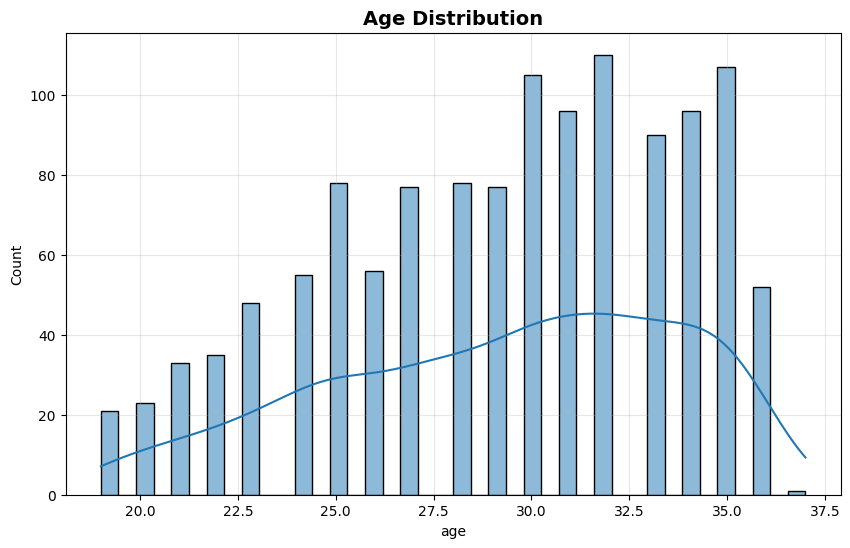

In [189]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=40)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

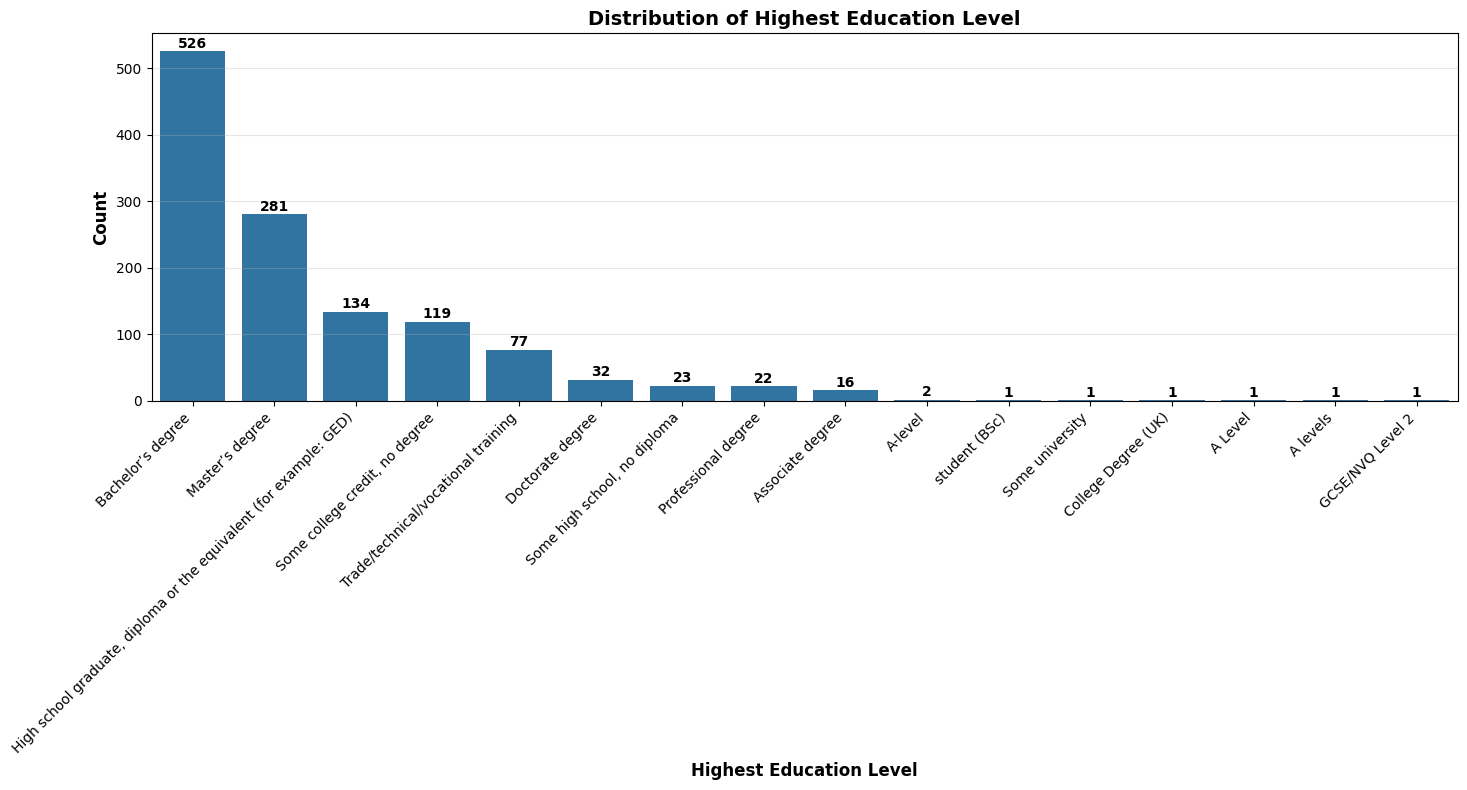

Education Level Distribution:
highest_education
Bachelor’s degree                                                     526
Master’s degree                                                       281
High school graduate, diploma or the equivalent (for example: GED)    134
Some college credit, no degree                                        119
Trade/technical/vocational training                                    77
Doctorate degree                                                       32
Some high school, no diploma                                           23
Professional degree                                                    22
Associate degree                                                       16
A-level                                                                 2
student (BSc)                                                           1
Some university                                                         1
College Degree (UK)                                             

In [137]:
# Distribution of highest education
plt.figure(figsize=(15, 8))

# Create a count plot instead of histogram since this is categorical data
ax = sns.countplot(data=df, x='highest_education', order=df['highest_education'].value_counts().index)

plt.title('Distribution of Highest Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Highest Education Level', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()  # This ensures labels don't get cut off
plt.show()

# Print the actual counts for reference
print("Education Level Distribution:")
print(df['highest_education'].value_counts())
print(f"\nTotal participants: {len(df)}")

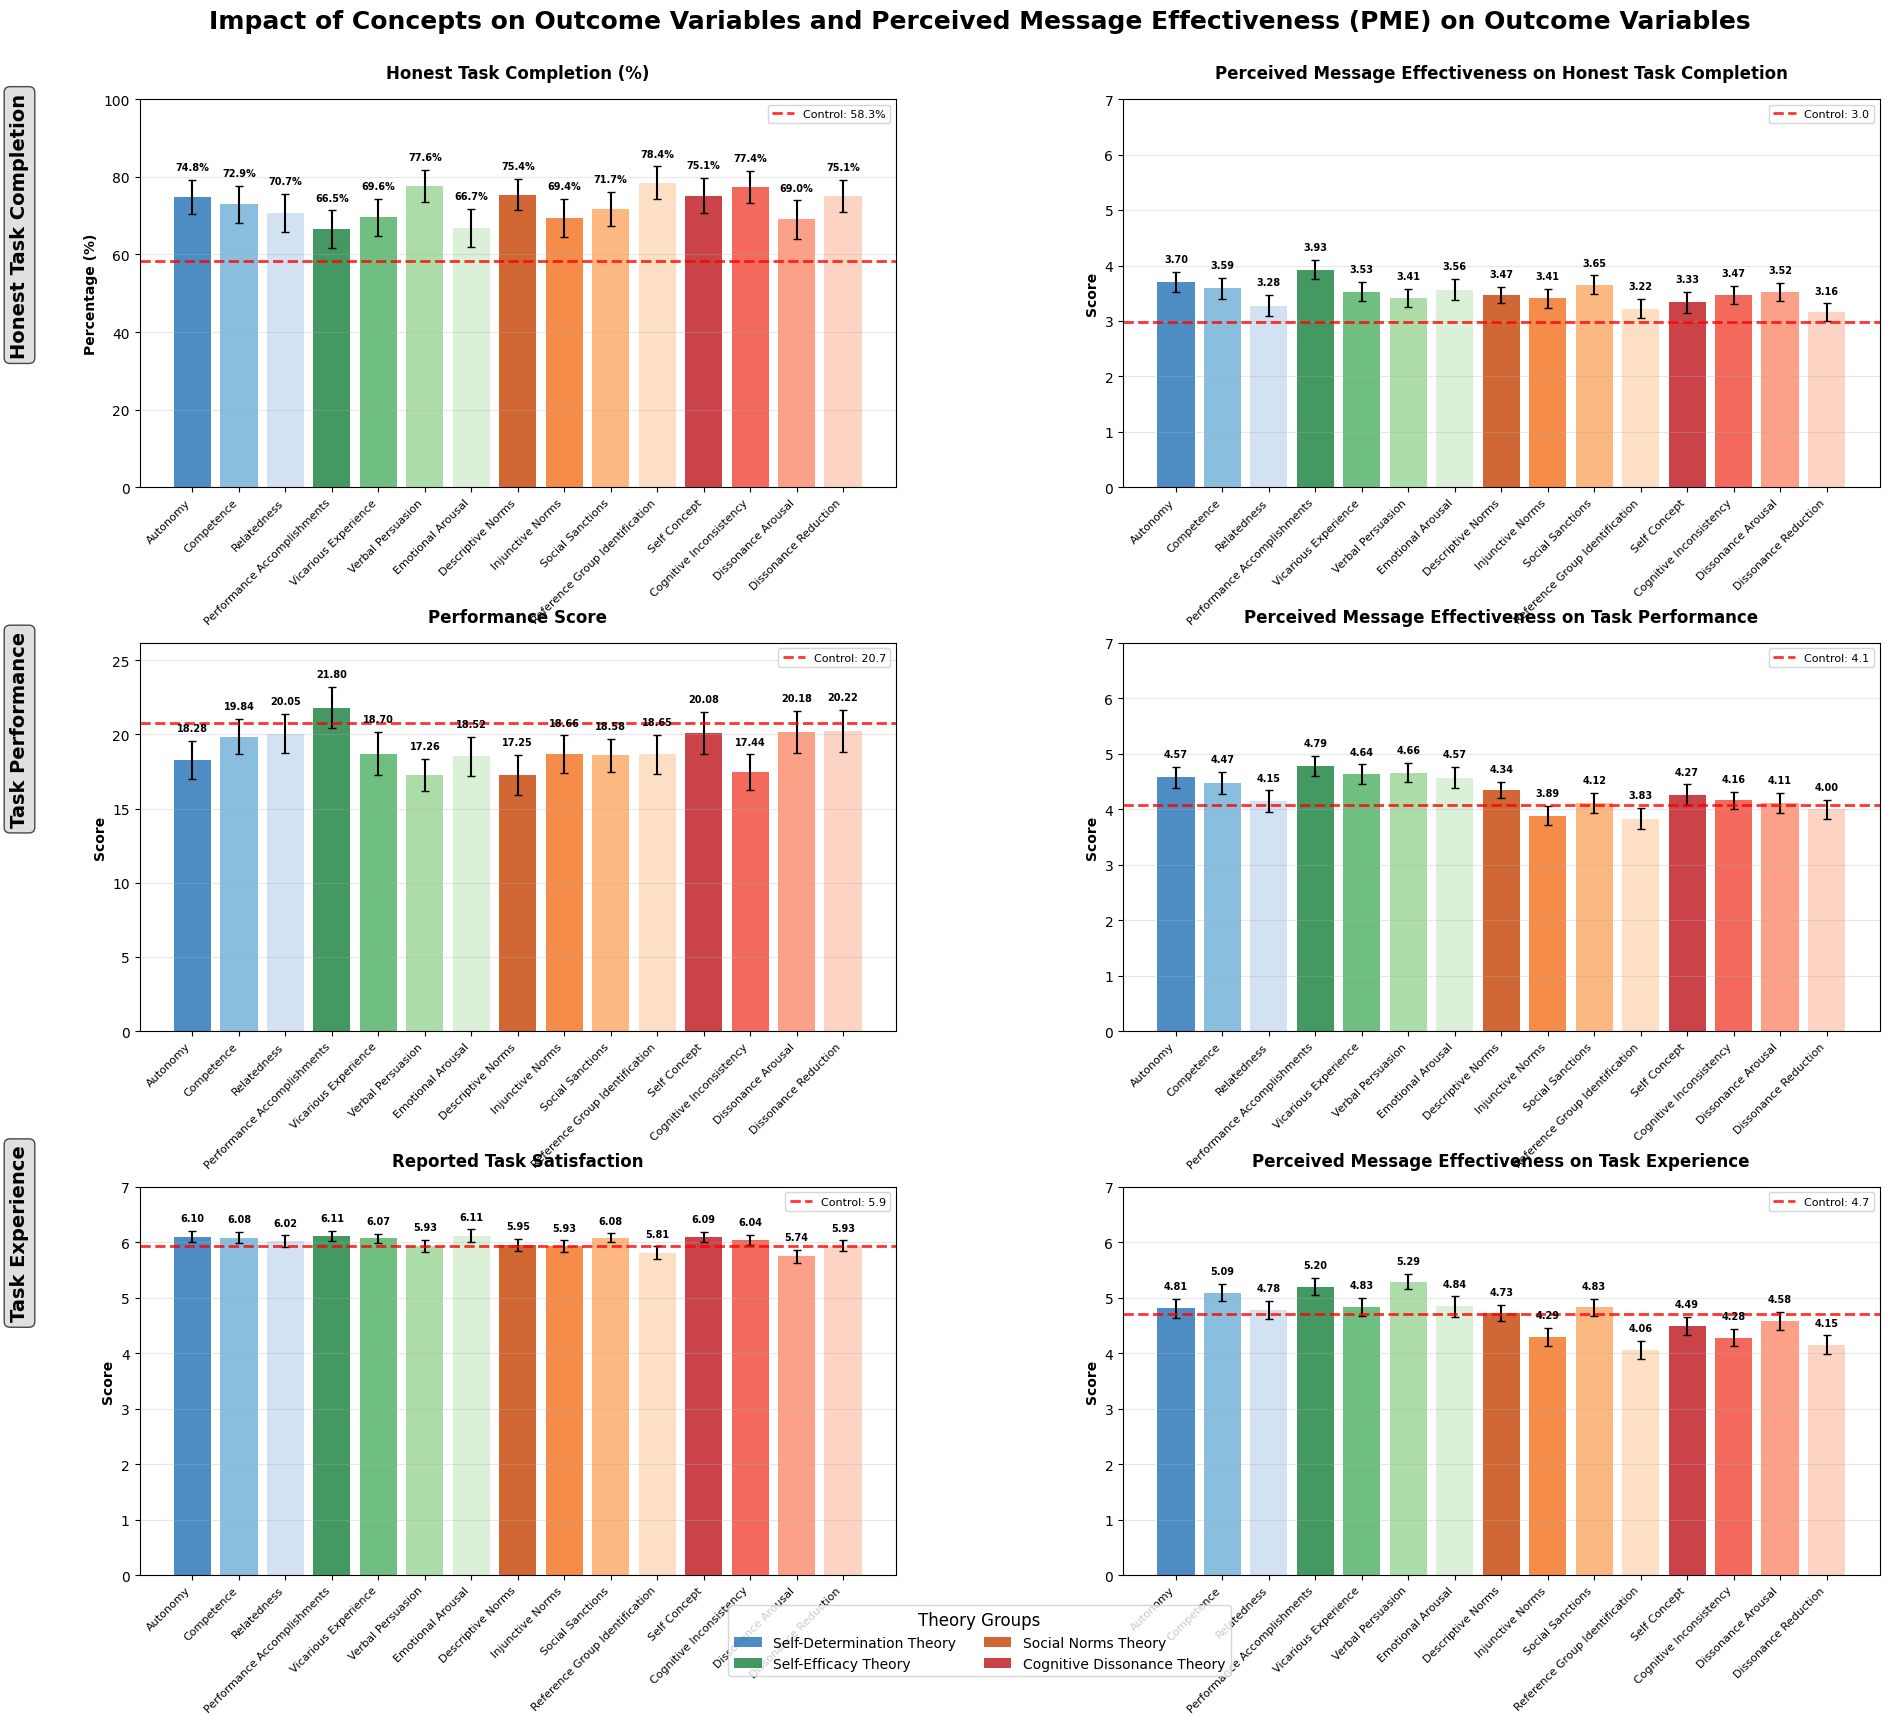


IMPROVED 3x2 GRID ANALYSIS SUMMARY
Control group size: 76 participants
Control continuous cheating rate: 0.417
Control honest completion: 58.3%
Control performance score: 20.74
Control task satisfaction: 5.94

Total concepts analyzed: 15
Theories included: ['Self-Determination Theory', 'Self-Efficacy Theory', 'Social Norms Theory', 'Cognitive Dissonance Theory']

Self-Determination Theory:
  - Autonomy: 74.8% (n=79) [↑ +16.5% vs control]
  - Competence: 72.9% (n=77) [↑ +14.6% vs control]
  - Relatedness: 70.7% (n=80) [↑ +12.4% vs control]

Self-Efficacy Theory:
  - Performance Accomplishments: 66.5% (n=80) [↑ +8.2% vs control]
  - Vicarious Experience: 69.6% (n=80) [↑ +11.3% vs control]
  - Verbal Persuasion: 77.6% (n=81) [↑ +19.3% vs control]
  - Emotional Arousal: 66.7% (n=80) [↑ +8.4% vs control]

Social Norms Theory:
  - Descriptive Norms: 75.4% (n=88) [↑ +17.1% vs control]
  - Injunctive Norms: 69.4% (n=79) [↑ +11.1% vs control]
  - Social Sanctions: 71.7% (n=83) [↑ +13.4% vs con

In [190]:
# Add concept and variation columns to dataframe
df['cheated'] = (df['cheating_rate_main_round'] > 0).astype(int)

# METHOD 2: CONTINUOUS 
cheating_stats = df.groupby(['theory', 'concept']).agg({
    'cheating_rate_main_round': ['mean', 'std', 'count'],
    'prolific_id': 'count'
})
cheating_stats.columns = ['avg_cheating_rate', 'cheating_rate_std', 'participant_count', 'participants']
cheating_stats['honest_completion_percentage'] = ((1 - cheating_stats['avg_cheating_rate']) * 100).round(1)
cheating_stats['honest_completion_se'] = (cheating_stats['cheating_rate_std'] / 
                                         np.sqrt(cheating_stats['participant_count']) * 100).fillna(0)

cheating_stats = cheating_stats.reset_index()

# Define theory-concept mappings with proper ordering
theory_concepts = {
    'Self-Determination Theory': ['autonomy', 'competence', 'relatedness'],
    'Self-Efficacy Theory': ['performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal'],
    'Social Norms Theory': ['descriptive_norms', 'injunctive_norms', 'social_sanctions', 'reference_group_identification'],
    'Cognitive Dissonance Theory': ['self_concept', 'cognitive_inconsistency', 'dissonance_arousal', 'dissonance_reduction']
}

# Create ordered list of all concepts with theory labels
all_concepts_ordered = []
theory_labels = []
for theory, concepts in theory_concepts.items():
    for concept in concepts:
        all_concepts_ordered.append(concept)
        theory_labels.append(theory)

# Create color mapping for theories
theory_colors = {
    'Self-Determination Theory': sns.color_palette("Blues_r", 3),
    'Self-Efficacy Theory': sns.color_palette("Greens_r", 4), 
    'Social Norms Theory': sns.color_palette("Oranges_r", 4),
    'Cognitive Dissonance Theory': sns.color_palette("Reds_r", 4)
}

# Create concept color mapping
concept_colors = {}
for theory, concepts in theory_concepts.items():
    colors = theory_colors[theory]
    for i, concept in enumerate(concepts):
        concept_colors[concept] = colors[i]

# Calculate concept averages for other metrics
df_concept_avg = df.copy()
for theory, concepts in theory_concepts.items():
    theory_data = df[df['theory'] == theory]
    for concept in concepts:
        concept_data = theory_data[theory_data['concept'] == concept]
        if len(concept_data) > 0:
            concept_means = concept_data.groupby('prolific_id')[
                ['performance_score_including_cheated_words', 'task_satisfaction', 'PME_on_honest_task_completion', 
                 'PME_on_task_performance', 'PME_on_task_experience']].mean()
            for prolific_id, row in concept_means.iterrows():
                mask = (df_concept_avg['prolific_id'] == prolific_id) & (df_concept_avg['concept'] == concept)
                for col in concept_means.columns:
                    df_concept_avg.loc[mask, col] = row[col]

# Merge honest completion data
df_concept_avg = df_concept_avg.merge(
    cheating_stats[['theory', 'concept', 'honest_completion_percentage', 'honest_completion_se']], 
    on=['theory', 'concept'], how='left')

# Calculate control values
control_data = df[df['theory'] == 'No Theory']
control_values = {}
if len(control_data) > 0:
    # For honest completion percentage
    control_stats = cheating_stats[(cheating_stats['theory'] == 'No Theory') & 
                                  (cheating_stats['concept'] == 'control')]
    if len(control_stats) > 0:
        control_values['honest_completion_percentage'] = control_stats['honest_completion_percentage'].iloc[0]
    else:
        control_cheating_rate = control_data['cheating_rate_main_round'].mean()
        control_values['honest_completion_percentage'] = (1 - control_cheating_rate) * 100
    
    # Other metrics
    control_means = control_data[['performance_score_including_cheated_words', 'task_satisfaction',
                                 'PME_on_honest_task_completion', 'PME_on_task_performance', 
                                 'PME_on_task_experience']].mean()
    for col, value in control_means.items():
        control_values[col] = value

# NEW 3x2 GRID PLOTTING SYSTEM
outcome_variable_groups = [
    {
        'row_title': 'Honest Task Completion',
        'observed': ('honest_completion_percentage', 'Honest Task Completion (%)', 'percentage'),
        'pme': ('PME_on_honest_task_completion', 'Perceived Message Effectiveness on Honest Task Completion', 'likert')
    },
    {
        'row_title': 'Task Performance', 
        'observed': ('performance_score_including_cheated_words', 'Performance Score', 'score'),
        'pme': ('PME_on_task_performance', 'Perceived Message Effectiveness on Task Performance', 'likert')
    },
    {
        'row_title': 'Task Experience',
        'observed': ('task_satisfaction', 'Reported Task Satisfaction', 'likert'),
        'pme': ('PME_on_task_experience', 'Perceived Message Effectiveness on Task Experience', 'likert')
    }
]

# Create the 3x2 grid plot
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Impact of Concepts on Outcome Variables and Perceived Message Effectiveness (PME) on Outcome Variables', 
             fontsize=18, fontweight='bold', y=0.95)

# Adjust spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3, left=0.08, right=0.95, top=0.90, bottom=0.08)

for row_idx, outcome_group in enumerate(outcome_variable_groups):
    row_title = outcome_group['row_title']
    
    # Add row title on the left
    fig.text(0.02, 0.83 - (row_idx * 0.28), row_title, fontsize=14, fontweight='bold', 
             rotation=90, ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    
    # Plot observed outcome (left column)
    ax_obs = axes[row_idx, 0]
    var_name_obs, var_label_obs, var_type_obs = outcome_group['observed']
    
    # Plot PME outcome (right column) 
    ax_pme = axes[row_idx, 1]
    var_name_pme, var_label_pme, var_type_pme = outcome_group['pme']
    
    # Process data for both plots
    for col_idx, (ax, var_name, var_label, var_type) in enumerate([
        (ax_obs, var_name_obs, var_label_obs, var_type_obs),
        (ax_pme, var_name_pme, var_label_pme, var_type_pme)
    ]):
        
        # Collect data for all concepts
        plot_data = []
        plot_labels = []
        plot_colors = []
        plot_errors = []
        plot_counts = []
        
        for concept in all_concepts_ordered:
            if var_name == 'honest_completion_percentage':
                # Handle honest completion percentage specially
                concept_data = cheating_stats[cheating_stats['concept'] == concept]
                if len(concept_data) > 0:
                    value = concept_data['honest_completion_percentage'].iloc[0]
                    error = concept_data['honest_completion_se'].iloc[0]
                    count = concept_data['participants'].iloc[0]
                else:
                    value = 0
                    error = 0
                    count = 0
            else:
                # Handle other variables
                concept_data = df_concept_avg[df_concept_avg['concept'] == concept]
                if len(concept_data) > 0 and var_name in concept_data.columns:
                    clean_data = concept_data[var_name].dropna()
                    if len(clean_data) > 0:
                        value = clean_data.mean()
                        error = clean_data.std() / np.sqrt(len(clean_data))  # Standard error
                        count = len(clean_data)
                    else:
                        value = 0
                        error = 0
                        count = 0
                else:
                    value = 0
                    error = 0
                    count = 0
            
            plot_data.append(value)
            plot_errors.append(error)
            plot_counts.append(count)
            plot_labels.append(concept.replace('_', ' ').title())
            plot_colors.append(concept_colors.get(concept, 'gray'))
        
        # Create bar plot
        x_pos = range(len(plot_data))
        bars = ax.bar(x_pos, plot_data, yerr=plot_errors, capsize=3, alpha=0.8, 
                      color=plot_colors)
        
        # Add control reference line
        if var_name in control_values:
            control_value = control_values[var_name]
            ax.axhline(y=control_value, color='red', linestyle='--', linewidth=2, 
                      alpha=0.8, label=f'Control: {control_value:.1f}{"%" if var_type == "percentage" else ""}')
        
        # Customize plot
        ax.set_title(var_label, fontweight='bold', fontsize=12, pad=15)
        
        if var_type == 'percentage':
            ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=10)
            ax.set_ylim(0, 100)
        else:
            ax.set_ylabel('Score', fontweight='bold', fontsize=10)
            if var_type == 'likert':
                ax.set_ylim(0, 7)
            else:
                ax.set_ylim(0, max(plot_data) * 1.2 if plot_data else 7)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, (bar, value, error, count) in enumerate(zip(bars, plot_data, plot_errors, plot_counts)):
            if count > 0:  # Only show labels for concepts with data
                height = bar.get_height()
                error_height = error if not pd.isna(error) else 0
                text_y = height + error_height + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
                
                if var_type == 'percentage':
                    ax.text(bar.get_x() + bar.get_width()/2, text_y,
                            f'{value:.1f}%', ha='center', va='bottom', 
                            fontsize=7, fontweight='bold')
                else:
                    ax.text(bar.get_x() + bar.get_width()/2, text_y,
                            f'{value:.2f}', ha='center', va='bottom', 
                            fontsize=7, fontweight='bold')
        
        # Add legend for control line
        if var_name in control_values:
            ax.legend(loc='upper right', fontsize=8)

# Add theory color legend
legend_elements = []
for theory, colors in theory_colors.items():
    # Use the first color of each theory as representative
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[0], alpha=0.8, label=theory))

fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, 
           title='Theory Groups', title_fontsize=12, bbox_to_anchor=(0.5, 0.02))

plt.show()

# Print summary statistics
print("\n" + "="*80)
print("IMPROVED 3x2 GRID ANALYSIS SUMMARY")
print("="*80)

control_data_summary = df[df['theory'] == 'No Theory']
if len(control_data_summary) > 0:
    print(f"Control group size: {len(control_data_summary)} participants")
    control_continuous_rate = control_data_summary['cheating_rate_main_round'].mean()
    print(f"Control continuous cheating rate: {control_continuous_rate:.3f}")
    print(f"Control honest completion: {control_values.get('honest_completion_percentage', 0):.1f}%")
    print(f"Control performance score: {control_values.get('performance_score_including_cheated_words', 0):.2f}")
    print(f"Control task satisfaction: {control_values.get('task_satisfaction', 0):.2f}")

print(f"\nTotal concepts analyzed: {len(all_concepts_ordered)}")
print(f"Theories included: {list(theory_concepts.keys())}")

# Print concept-wise summary with theory grouping
for theory, concepts in theory_concepts.items():
    print(f"\n{theory}:")
    theory_stats = cheating_stats[cheating_stats['theory'] == theory]
    for concept in concepts:
        concept_stats = theory_stats[theory_stats['concept'] == concept]
        if len(concept_stats) > 0:
            row = concept_stats.iloc[0]
            concept_name = concept.replace('_', ' ').title()
            honest_pct = row['honest_completion_percentage']
            participant_count = row['participants']
            diff_from_control = honest_pct - control_values.get('honest_completion_percentage', 0)
            direction = "↑" if diff_from_control > 0 else "↓" if diff_from_control < 0 else "="
            print(f"  - {concept_name}: {honest_pct}% (n={participant_count}) [{direction} {diff_from_control:+.1f}% vs control]")

In [147]:
# Building on existing code from analysis.ipynb
# This assumes you've already run the previous sections that created:
# - df with all the calculated variables
# - all_concepts_ordered list
# - cheating_stats dataframe

import pandas as pd
import numpy as np

# Add control to the concepts list
all_concepts_with_control = ['control'] + all_concepts_ordered

# Create comprehensive results dataframe
results_data = []

for concept in all_concepts_with_control:
    # Get concept data
    concept_data = df[df['concept'] == concept]
    
    if len(concept_data) == 0:
        continue
    
    # Get theory for this concept
    theory = concept_data['theory'].iloc[0] if len(concept_data) > 0 else 'Unknown'
    
    # Initialize row
    row = {
        'concept': concept,
        'theory': theory,
        'n_participants': len(concept_data)
    }
    
    # Variables to calculate averages for
    variables = [
        'performance_score_including_cheated_words',
        'performance_score_excluding_cheated_words', 
        'task_satisfaction',
        'PME_on_honest_task_completion',
        'PME_on_task_performance',
        'PME_on_task_experience',
        'autonomy_need_fulfillment', 
        'competence_need_fulfillment', 
        'relatedness_need_fulfillment',
        'performance_accomplishments', 
        'vicarious_experience', 
        'verbal_persuasion', 
        'emotional_arousal',
        'injunctive_norms', 
        'descriptive_norms', 
        'reference_group_identification', 
        'social_sanctions',
        'cognitive_discomfort', 
        'moral_disengagement'
    ]
    
    # Calculate means and SEs for each variable
    for var in variables:
        if var in concept_data.columns:
            clean_data = concept_data[var].dropna()
            if len(clean_data) > 0:
                mean_val = clean_data.mean()
                se_val = clean_data.std() / np.sqrt(len(clean_data))
                row[f'{var}_mean'] = round(mean_val, 3)
                row[f'{var}_se'] = round(se_val, 3)
            else:
                row[f'{var}_mean'] = np.nan
                row[f'{var}_se'] = np.nan
        else:
            row[f'{var}_mean'] = np.nan
            row[f'{var}_se'] = np.nan
    
    # Add honest completion data from existing cheating_stats
    concept_stats = cheating_stats[cheating_stats['concept'] == concept]
    if len(concept_stats) > 0:
        row['honest_task_completion_mean'] = concept_stats['honest_completion_percentage'].iloc[0]
        row['honest_task_completion_se'] = concept_stats['honest_completion_se'].iloc[0]
    else:
        # Calculate manually if not in cheating_stats
        cheating_rate = concept_data['cheating_rate_main_round'].mean()
        honest_completion = (1 - cheating_rate) * 100
        honest_completion_se = (concept_data['cheating_rate_main_round'].std() / 
                               np.sqrt(len(concept_data))) * 100
        row['honest_task_completion_mean'] = round(honest_completion, 3)
        row['honest_task_completion_se'] = round(honest_completion_se, 3)
    
    results_data.append(row)

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Reorder columns for better readability
column_order = ['concept', 'theory', 'n_participants']
for var in ['honest_task_completion', 'performance_score_including_cheated_words', 
            'performance_score_excluding_cheated_words', 'task_satisfaction',
            'PME_on_honest_task_completion', 'PME_on_task_performance', 'PME_on_task_experience',
            'autonomy_need_fulfillment', 'competence_need_fulfillment', 'relatedness_need_fulfillment',
            'performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal',
            'injunctive_norms', 'descriptive_norms', 'reference_group_identification', 'social_sanctions',
            'cognitive_discomfort', 'moral_disengagement']:
    column_order.extend([f'{var}_mean', f'{var}_se'])

results_df = results_df[column_order]

# Sort by theory and concept
results_df = results_df.sort_values(['theory', 'concept'])

# Save to CSV
results_df.to_csv('../data/concept_averages_with_se.csv', index=False)

print("Concept averages with standard errors saved to '../data/concept_averages_with_se.csv'")
print(f"\nDataset shape: {results_df.shape}")
print("\nFirst few rows:")
print(results_df.head())

# Display summary
print(f"\nSummary:")
print(f"Total concepts: {len(results_df)}")
print(f"Theories: {results_df['theory'].unique()}")
print(f"Participant range: {results_df['n_participants'].min()} - {results_df['n_participants'].max()}")

Concept averages with standard errors saved to '../data/concept_averages_with_se.csv'

Dataset shape: (16, 43)

First few rows:
                    concept                       theory  n_participants  \
13  cognitive_inconsistency  Cognitive Dissonance Theory              76   
14       dissonance_arousal  Cognitive Dissonance Theory              80   
15     dissonance_reduction  Cognitive Dissonance Theory              82   
12             self_concept  Cognitive Dissonance Theory              78   
0                   control                    No Theory              75   

    honest_task_completion_mean  honest_task_completion_se  \
13                         77.2                   4.308079   
14                         69.0                   4.901788   
15                         75.1                   4.137823   
12                         75.1                   4.502921   
0                          59.0                   5.363757   

    performance_score_including_cheated_wo

/var/folders/9x/l7cjx6vd0518z9mfnzrvbtt97pcxk7/T/ipykernel_49491/2717253709.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


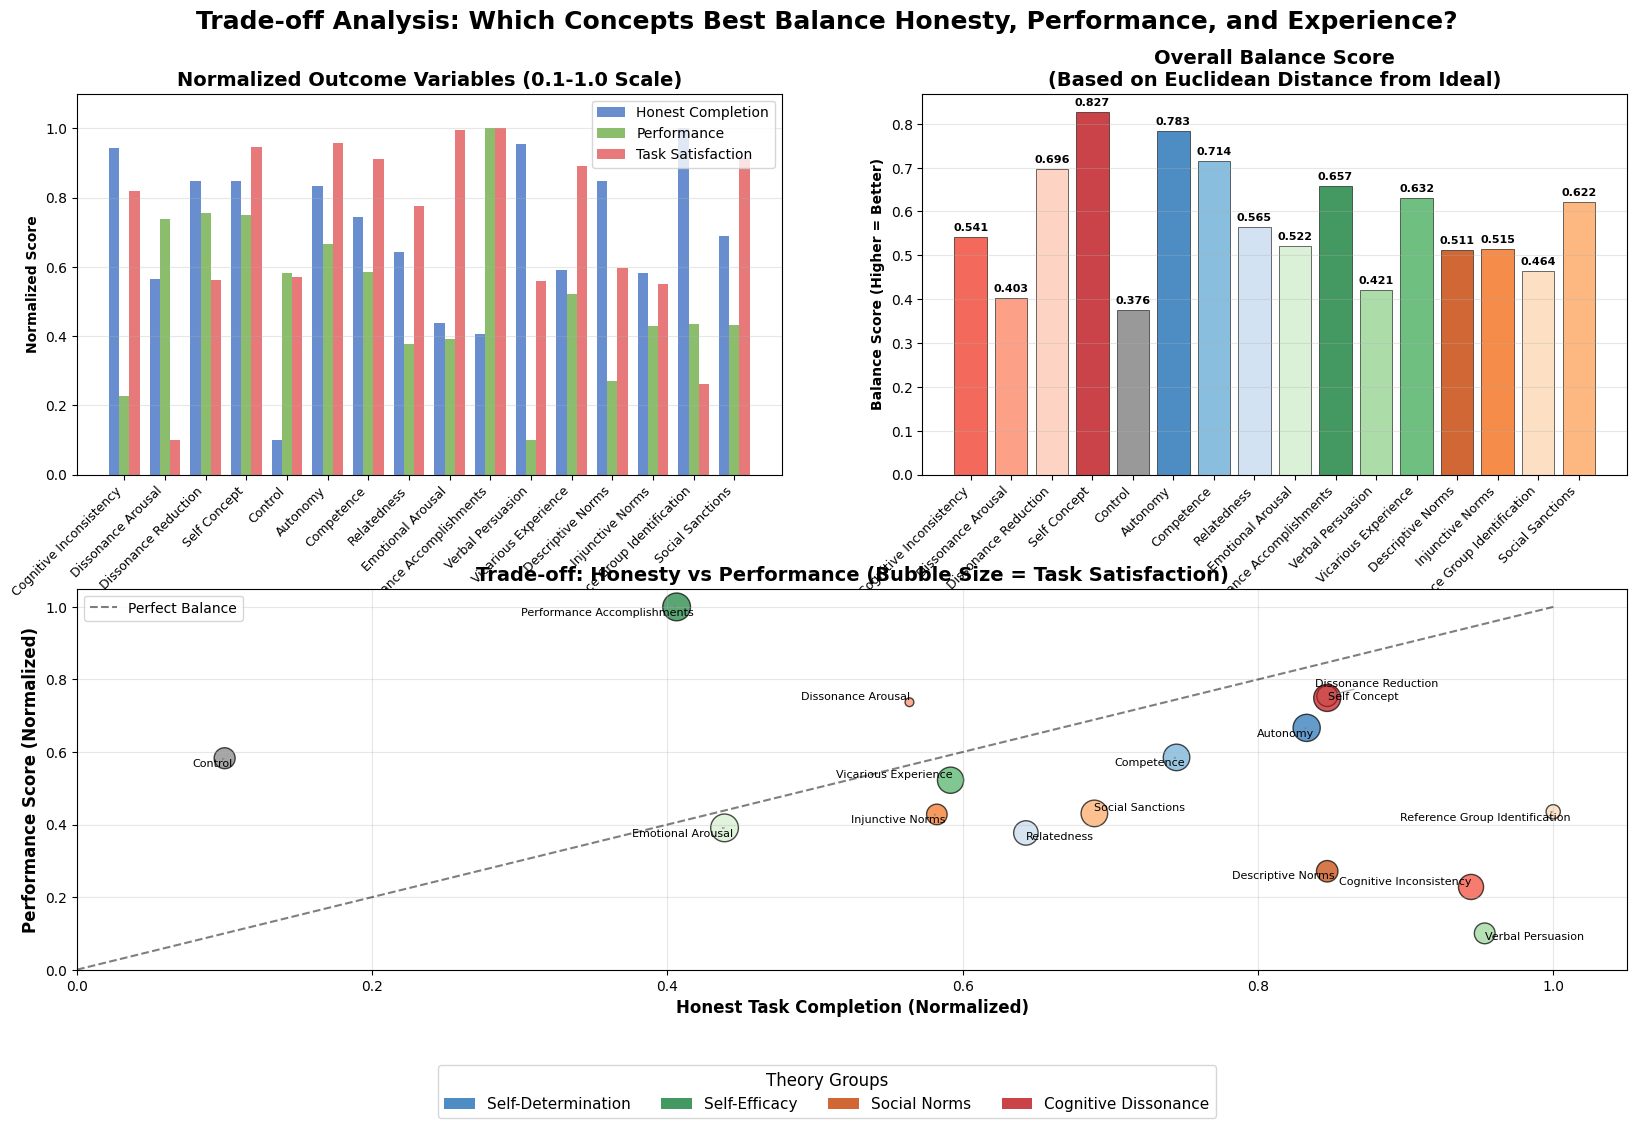


=== TRADE-OFF ANALYSIS RESULTS ===
Research Question: Which theoretical concepts are most effective for promoting
honest task completion without sacrificing performance or experience?

Top 5 Most Balanced Concepts (Highest Overall Balance Score):
------------------------------------------------------------
1. Self Concept
   Theory: Cognitive Dissonance Theory
   Balance Score: 0.827
   Honest Completion: 75.1%
   Performance: 5.80
   Satisfaction: 6.09

2. Autonomy
   Theory: Self-Determination Theory
   Balance Score: 0.783
   Honest Completion: 74.8%
   Performance: 5.65
   Satisfaction: 6.10

3. Competence
   Theory: Self-Determination Theory
   Balance Score: 0.714
   Honest Completion: 72.9%
   Performance: 5.50
   Satisfaction: 6.08

4. Dissonance Reduction
   Theory: Cognitive Dissonance Theory
   Balance Score: 0.696
   Honest Completion: 75.1%
   Performance: 5.81
   Satisfaction: 5.93

5. Performance Accomplishments
   Theory: Self-Efficacy Theory
   Balance Score: 0.657
  

In [175]:
from adjustText import adjust_text

# Load the concept averages data
concept_df = pd.read_csv('../data/concept_averages_with_se.csv')

# Select the three main outcome variables
outcome_vars = ['honest_task_completion_mean', 'performance_score_including_cheated_words_mean', 'task_satisfaction_mean']

# Robust Min-Max normalization to 0.1-1.0 range (avoids misleading zeros)
for var in outcome_vars:
    min_val = concept_df[var].min()
    max_val = concept_df[var].max()
    # Scale to 0.1-1.0 to avoid artificial zeros
    concept_df[f'{var}_normalized'] = 0.1 + 0.9 * (concept_df[var] - min_val) / (max_val - min_val)

# Calculate balance score based on Euclidean distance from ideal (1,1,1)
normalized_vars = [f'{var}_normalized' for var in outcome_vars]
concept_df['distance_from_ideal'] = np.sqrt(
    sum((1 - concept_df[var])**2 for var in normalized_vars)
)
concept_df['balance_score'] = 1 - concept_df['distance_from_ideal'] / np.sqrt(3)  # Normalized by max possible distance

# Create color mapping (reuse from analysis.ipynb)
theory_colors = {
    'Self-Determination Theory': sns.color_palette("Blues_r", 3),
    'Self-Efficacy Theory': sns.color_palette("Greens_r", 4), 
    'Social Norms Theory': sns.color_palette("Oranges_r", 4),
    'Cognitive Dissonance Theory': sns.color_palette("Reds_r", 4)
}

theory_concepts = {
    'Self-Determination Theory': ['autonomy', 'competence', 'relatedness'],
    'Self-Efficacy Theory': ['performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal'],
    'Social Norms Theory': ['descriptive_norms', 'injunctive_norms', 'social_sanctions', 'reference_group_identification'],
    'Cognitive Dissonance Theory': ['self_concept', 'cognitive_inconsistency', 'dissonance_arousal', 'dissonance_reduction']
}

concept_colors = {}
for theory, concepts in theory_concepts.items():
    colors = theory_colors[theory]
    for i, concept in enumerate(concepts):
        concept_colors[concept] = colors[i]

# Create improved 2x2 layout
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1], 
              hspace=0.3, wspace=0.2)

fig.suptitle('Trade-off Analysis: Which Concepts Best Balance Honesty, Performance, and Experience?', 
             fontsize=18, fontweight='bold', y=0.95)

colors = [concept_colors.get(concept, 'gray') for concept in concept_df['concept']]
concept_labels = [c.replace('_', ' ').title() for c in concept_df['concept']]

# Plot 1: Normalized outcomes (top left)
ax1 = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(concept_df))
width = 0.25

bars_hon = ax1.bar(x_pos - width, concept_df['honest_task_completion_mean_normalized'], 
                   width, label='Honest Completion', alpha=0.8, color='#4472C4')
bars_perf = ax1.bar(x_pos, concept_df['performance_score_including_cheated_words_mean_normalized'], 
                    width, label='Performance', alpha=0.8, color='#70AD47')
bars_sat = ax1.bar(x_pos + width, concept_df['task_satisfaction_mean_normalized'], 
                   width, label='Task Satisfaction', alpha=0.8, color='#E15759')

ax1.set_title('Normalized Outcome Variables (0.1-1.0 Scale)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Normalized Score', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(concept_labels, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Balance scores (top right)
ax2 = fig.add_subplot(gs[0, 1])
bars_balance = ax2.bar(range(len(concept_df)), concept_df['balance_score'], 
                       color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax2.set_title('Overall Balance Score\n(Based on Euclidean Distance from Ideal)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Balance Score (Higher = Better)', fontweight='bold')
ax2.set_xticks(range(len(concept_df)))
ax2.set_xticklabels(concept_labels, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on balance score bars
for i, (bar, value) in enumerate(zip(bars_balance, concept_df['balance_score'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 3: Trade-off scatter plot (bottom, spanning both columns)
ax3 = fig.add_subplot(gs[1, :])
scatter = ax3.scatter(concept_df['honest_task_completion_mean_normalized'], 
                      concept_df['performance_score_including_cheated_words_mean_normalized'],
                      s=concept_df['task_satisfaction_mean_normalized'] * 400,
                      c=colors, alpha=0.7, edgecolors='black', linewidth=1)

# Add concept labels to scatter plot
texts = []
for i, concept in enumerate(concept_df['concept']):
    text = ax3.annotate(concept.replace('_', ' ').title(), 
                       (concept_df['honest_task_completion_mean_normalized'].iloc[i],
                        concept_df['performance_score_including_cheated_words_mean_normalized'].iloc[i]),
                       fontsize=8, ha='center', va='center')
    texts.append(text)

adjust_text(texts, ax=ax3, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6))

ax3.set_xlabel('Honest Task Completion (Normalized)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Performance Score (Normalized)', fontweight='bold', fontsize=12)
ax3.set_title('Trade-off: Honesty vs Performance (Bubble Size = Task Satisfaction)', 
              fontweight='bold', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 1.05)
ax3.set_ylim(0, 1.05)

# Add ideal point reference
# ax3.scatter([1], [1], s=100, color='red', marker='*', edgecolors='darkred', 
#             linewidth=2, label='Ideal Point (1,1)', zorder=10)
# ax3.legend(loc='lower left', fontsize=10)

# Add theory color legend
legend_elements = []
for theory, theory_color_list in theory_colors.items():
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=theory_color_list[0], 
                                        alpha=0.8, label=theory.replace(' Theory', '')))

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11, 
           title='Theory Groups', title_fontsize=12, bbox_to_anchor=(0.5, 0.02))

# Add diagonal line (perfect trade-off)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Balance')
ax3.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# Print analysis results
print("\n=== TRADE-OFF ANALYSIS RESULTS ===")
print("Research Question: Which theoretical concepts are most effective for promoting")
print("honest task completion without sacrificing performance or experience?")
print("="*80)

# Sort by balance score and show top 5
top_concepts = concept_df.nlargest(5, 'balance_score')
print("\nTop 5 Most Balanced Concepts (Highest Overall Balance Score):")
print("-" * 60)
for i, (idx, row) in enumerate(top_concepts.iterrows(), 1):
    print(f"{i}. {row['concept'].replace('_', ' ').title()}")
    print(f"   Theory: {row['theory']}")
    print(f"   Balance Score: {row['balance_score']:.3f}")
    print(f"   Honest Completion: {row['honest_task_completion_mean']:.1f}%")
    print(f"   Performance: {row['performance_score_including_cheated_words_mean']:.2f}")
    print(f"   Satisfaction: {row['task_satisfaction_mean']:.2f}")
    print()

# Show the best overall concept details
best_concept = concept_df.loc[concept_df['balance_score'].idxmax()]
print(f"WINNER: {best_concept['concept'].replace('_', ' ').title()}")
print(f"This concept from {best_concept['theory']} achieves the best balance")
print(f"across all three outcome dimensions with a score of {best_concept['balance_score']:.3f}")
print("="*80)

In [176]:

concept_df = pd.read_csv('../data/concept_averages_with_se.csv')

print("Reusing variables from analysis.ipynb trade-off section...")

# Exact code from RQ1: TRADE-OFF ANALYSIS section in analysis.ipynb
outcome_vars = ['honest_task_completion_mean', 'performance_score_including_cheated_words_mean', 'task_satisfaction_mean']

# Robust Min-Max normalization to 0.1-1.0 range (avoids misleading zeros)
for var in outcome_vars:
    min_val = concept_df[var].min()
    max_val = concept_df[var].max()
    # Scale to 0.1-1.0 to avoid artificial zeros
    concept_df[f'{var}_normalized'] = 0.1 + 0.9 * (concept_df[var] - min_val) / (max_val - min_val)

# Calculate balance score based on Euclidean distance from ideal (1,1,1)
normalized_vars = [f'{var}_normalized' for var in outcome_vars]
concept_df['distance_from_ideal'] = np.sqrt(
    sum((1 - concept_df[var])**2 for var in normalized_vars)
)
concept_df['balance_score'] = 1 - concept_df['distance_from_ideal'] / np.sqrt(3)  # Normalized by max possible distance

# Save outcome data (all variables used in plots)
outcome_export = concept_df[['concept', 'theory', 'n_participants', 
                           'honest_task_completion_mean', 'honest_task_completion_se',
                           'performance_score_including_cheated_words_mean', 'performance_score_including_cheated_words_se',
                           'task_satisfaction_mean', 'task_satisfaction_se',
                           'PME_on_honest_task_completion_mean', 'PME_on_honest_task_completion_se',
                           'PME_on_task_performance_mean', 'PME_on_task_performance_se',
                           'PME_on_task_experience_mean', 'PME_on_task_experience_se']].copy()

outcome_export.to_csv('../data/python_outcome_plot_data.csv', index=False)

# Save tradeoff data  
tradeoff_export = concept_df[['concept', 'theory', 'n_participants',
                            'honest_task_completion_mean', 'performance_score_including_cheated_words_mean', 'task_satisfaction_mean',
                            'honest_task_completion_mean_normalized', 'performance_score_including_cheated_words_mean_normalized', 'task_satisfaction_mean_normalized',
                            'balance_score']].copy()

tradeoff_export = tradeoff_export.sort_values('balance_score', ascending=False)
tradeoff_export.to_csv('../data/python_tradeoff_plot_data.csv', index=False)

print(f"✓ Saved python_outcome_plot_data.csv ({len(outcome_export)} concepts)")
print(f"✓ Saved python_tradeoff_plot_data.csv ({len(tradeoff_export)} concepts)")

print(f"\nTop 5 balanced concepts (Python analysis.ipynb):")
for i, (_, row) in enumerate(tradeoff_export.head(5).iterrows(), 1):
    print(f"{i}. {row['concept']}: {row['balance_score']:.3f}")

Reusing variables from analysis.ipynb trade-off section...
✓ Saved python_outcome_plot_data.csv (16 concepts)
✓ Saved python_tradeoff_plot_data.csv (16 concepts)

Top 5 balanced concepts (Python analysis.ipynb):
1. self_concept: 0.827
2. autonomy: 0.783
3. competence: 0.714
4. dissonance_reduction: 0.696
5. performance_accomplishments: 0.657


In [141]:
# total count of cheating_main_round by concept
cheating_counts = df.groupby('concept')['cheating_main_round'].sum().reset_index()
cheating_counts

,concept,cheating_main_round
0,Unknown,3
1,autonomy,27
2,cognitive_inconsistency,26
3,competence,27
4,control,37
5,descriptive_norms,31
6,dissonance_arousal,30
7,dissonance_reduction,32
8,emotional_arousal,34
9,injunctive_norms,32


In [ ]:
# ===============================================================
# PLOTTING ALL THEORETICAL MEASUREMENTS FOR EACH CONCEPT INDIVIDUALLY
# AND SAVING TO PDF WITH PROPERLY ALIGNED CONTROL REFERENCE LINES
# ===============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# Define all theoretical measurements you want to analyze
theoretical_measurements = [
    ('autonomy_need_fulfillment', 'Autonomy Need Fulfillment'),
    ('competence_need_fulfillment', 'Competence Need Fulfillment'),
    ('relatedness_need_fulfillment', 'Relatedness Need Fulfillment'),
    ('overall_need_fulfillment', 'Psychological Need Fulfillment'),
    ('performance_accomplishments', 'Performance Accomplishments'),
    ('vicarious_experience', 'Vicarious Experience'),
    ('verbal_persuasion', 'Verbal Persuasion'),
    ('emotional_arousal', 'Emotional Arousal'),
    ('task_specific_self_efficacy', 'Task Specific Self-Efficacy'),
    ('injunctive_norms', 'Injunctive Norms'),
    ('descriptive_norms', 'Descriptive Norms'),
    ('reference_group_identification', 'Reference Group Identification'),
    ('social_sanctions', 'Social Sanctions'),
    ('norm_perception', 'Norm Perception'),
    ('cognitive_discomfort', 'Cognitive Discomfort'),
    ('moral_disengagement', 'Moral Disengagement')
]

# Define theory-concept mappings (using exact theory names from dataset)
theory_concepts = {
    'Self-Determination Theory': ['autonomy', 'competence', 'relatedness'],
    'Self-Efficacy Theory': ['performance_accomplishments', 'vicarious_experience', 'verbal_persuasion', 'emotional_arousal'],
    'Social Norms Theory': ['injunctive_norms', 'descriptive_norms', 'reference_group_identification', 'social_sanctions'],
    'Cognitive Dissonance Theory': ['dissonance_arousal', 'dissonance_reduction', 'cognitive_inconsistency', 'self_concept']
}

# ===============================================================
# CALCULATE CONTROL VALUES FOR ALL THEORETICAL MEASUREMENTS
# ===============================================================

# Extract control group data
control_data = df_concept_avg[df_concept_avg['theory'] == 'No Theory']
control_values = {}

if len(control_data) > 0:
    print(f"Control group size: {len(control_data)} participants")
    print("Calculating control values for theoretical measurements...")
    
    # Calculate control means for all theoretical measurements
    for var_name, var_label in theoretical_measurements:
        if var_name in control_data.columns:
            # Remove missing values and calculate mean
            clean_control_data = control_data[var_name].dropna()
            if len(clean_control_data) > 0:
                control_values[var_name] = clean_control_data.mean()
                print(f"  Control {var_label}: {control_values[var_name]:.3f}")
            else:
                print(f"  Warning: No valid control data for {var_label}")
        else:
            print(f"  Warning: {var_label} not found in control data")
else:
    print("Warning: No control group data found!")

print(f"Control values calculated for {len(control_values)} measurements")

# Get all unique concepts across all theories
all_concepts = []
for concepts in theory_concepts.values():
    all_concepts.extend(concepts)

# Define the output PDF path
output_path = Path('../data/theoretical_measurements_by_concept_with_control.pdf')

print(f"Creating PDF with properly aligned control reference lines: {output_path}")

# Create PDF file to save all plots
with PdfPages(output_path) as pdf:
    
    # Create individual plots for each concept
    for concept_idx, concept in enumerate(all_concepts):
        print(f"Processing concept {concept_idx + 1}/{len(all_concepts)}: {concept}")
        
        # Find which theory this concept belongs to
        concept_theory = None
        for theory, concepts in theory_concepts.items():
            if concept in concepts:
                concept_theory = theory
                break
        
        if concept_theory is None:
            print(f"Warning: No theory found for concept: {concept}")
            continue
        
        # Filter data for this specific concept
        concept_data = df_concept_avg[
            (df_concept_avg['theory'] == concept_theory) & 
            (df_concept_avg['concept'] == concept)
        ].copy()
        
        if len(concept_data) == 0:
            print(f"No data found for concept: {concept}")
            continue
        
        # Create figure for this concept
        fig, ax = plt.subplots(1, 1, figsize=(16, 8))
        
        # Calculate means and standard errors for all theoretical measurements
        measurement_stats = []
        measurement_labels = []
        control_line_values = []
        
        for var_name, var_label in theoretical_measurements:
            if var_name in concept_data.columns:
                # Remove missing values
                clean_data = concept_data[var_name].dropna()
                
                if len(clean_data) > 0:
                    mean_val = clean_data.mean()
                    std_val = clean_data.std()
                    count = len(clean_data)
                    se_val = std_val / np.sqrt(count)  # Standard error
                    
                    measurement_stats.append({
                        'mean': mean_val,
                        'std': std_val,
                        'se': se_val,
                        'count': count
                    })
                    measurement_labels.append(var_label)
                    
                    # Add control value for this measurement
                    control_line_values.append(control_values.get(var_name, None))
                else:
                    measurement_stats.append({
                        'mean': 0,
                        'std': 0,
                        'se': 0,
                        'count': 0
                    })
                    measurement_labels.append(var_label)
                    control_line_values.append(None)
            else:
                # Variable not found, add zero values
                measurement_stats.append({
                    'mean': 0,
                    'std': 0,
                    'se': 0,
                    'count': 0
                })
                measurement_labels.append(var_label)
                control_line_values.append(None)
        
        if not measurement_stats:
            print(f"No valid measurements found for concept: {concept}")
            plt.close(fig)
            continue
        
        # Extract data for plotting
        means = [stat['mean'] for stat in measurement_stats]
        std_errors = [stat['se'] for stat in measurement_stats]
        counts = [stat['count'] for stat in measurement_stats]
        
        # Create bar plot
        x_pos = range(len(measurement_labels))
        bars = ax.bar(x_pos, means, yerr=std_errors, capsize=3, alpha=0.7, 
                      color=sns.color_palette("viridis", len(measurement_labels)))
        
        # ADD PROPERLY ALIGNED CONTROL REFERENCE LINES
        bar_width = bars[0].get_width()
        for i, (x, control_val) in enumerate(zip(x_pos, control_line_values)):
            if control_val is not None and means[i] > 0:  # Only show control lines for measurements with data
                # Draw a red horizontal line spanning the width of each bar
                line_start = x - bar_width/2
                line_end = x + bar_width/2
                ax.plot([line_start, line_end], [control_val, control_val], 
                       color='red', linestyle='--', linewidth=2, alpha=0.8)
        
        # Customize the plot
        concept_title = concept.replace('_', ' ').title()
        ax.set_title(f'{concept_title} ({concept_theory})', 
                     fontweight='bold', fontsize=14, pad=20)
        ax.set_xlabel('Theoretical Measurements', fontweight='bold', fontsize=12)
        ax.set_ylabel('Mean Score', fontweight='bold', fontsize=12)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(measurement_labels, rotation=45, ha='right', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Set appropriate y-axis limits (typically 1-7 for Likert scales)
        y_min = min([m for m in means if m > 0] + [c for c in control_line_values if c is not None], default=1)
        y_max = max(means + [c for c in control_line_values if c is not None], default=7)
        ax.set_ylim(max(0.5, y_min - 0.5), min(7.5, y_max + 0.5))
        
        # Add value labels on bars
        for i, (bar, mean_val, count, control_val) in enumerate(zip(bars, means, counts, control_line_values)):
            if count > 0:  # Only show labels for measurements with data
                height = bar.get_height()
                error_height = std_errors[i]
                text_y = height + error_height + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
                
                # label with just mean and sample size
                ax.text(bar.get_x() + bar.get_width()/2, text_y,
                        f'{mean_val:.2f}\n(n={count})', 
                        ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')
            else:
                # Mark measurements with no data
                ax.text(bar.get_x() + bar.get_width()/2, 0.2,
                        'No data', ha='center', va='bottom', 
                        fontsize=8, style='italic', color='red')
        
        # Add simple concept info
        total_participants = concept_data['prolific_id'].nunique()
        
        info_text = f'Message: {concept_title}\nParticipants: {total_participants}'
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
                fontsize=10, va='top', fontweight='bold')
        
        # Add simple legend
        legend_text = 'Red dashed lines: Control group mean'
        ax.text(0.98, 0.02, legend_text, transform=ax.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
                fontsize=9, va='bottom', ha='right')
        
        plt.tight_layout()
        
        # Save the current figure to PDF
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        
        # Close the figure to free memory
        plt.close(fig)

print(f"PDF successfully created: {output_path}")
print(f"Total plots saved: {len(all_concepts)} concept plots + 1 summary page")
print("All plots with properly aligned control reference lines have been saved.")

# Print summary to console
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

if len(control_data) > 0:
    print(f"Control group: {len(control_data)} participants")
    print(f"Control values available for: {len(control_values)} measurements")
    print(f"Concepts analyzed: {len(all_concepts)}")
    
    # Count total participants per theory
    print("\nParticipants by theory:")
    for theory in theory_concepts.keys():
        theory_participants = df_concept_avg[df_concept_avg['theory'] == theory]['prolific_id'].nunique()
        if theory_participants > 0:
            print(f"  {theory}: {theory_participants} participants")
else:
    print("No control group data available")

print(f"\nPDF file created: {output_path}")

In [ ]:
# Count actual cheating instances by concept (sum across all variations)
# Create binary cheating indicator (1 if cheating_rate_main_round > 0, 0 otherwise)
df['cheated'] = (df['cheating_rate_main_round'] > 0).astype(int)

cheating_by_concept = df.groupby(['theory', 'concept']).agg({
    'cheated': 'sum',  # Total cheating instances across all variations
    'prolific_id': 'count'  # Total participants
})

# Calculate cheating percentage
cheating_by_concept['cheating_percentage'] = (cheating_by_concept['cheated'] / 
                                            cheating_by_concept['prolific_id'] * 100).round(1)

# Rename columns for clarity
cheating_by_concept = cheating_by_concept.rename(columns={
    'cheated': 'cheating_instances', 
    'prolific_id': 'total_participants'
})

print("Cheating by Theory and Concept:")
print("=" * 50)
print(cheating_by_concept[['total_participants', 'cheating_instances', 'cheating_percentage']])

In [ ]:
#show prolific ids of participants who have concept as control and cheating_rate_main_round = 0.0
control_participants = df[(df['theory'] == 'No Theory') & (df['cheating_rate_main_round'] == 0.0)]
print(control_participants)